# 0. Setup

In [2]:
!uv sync

'uv' is not recognized as an internal or external command,
operable program or batch file.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
import math

# 1. Data Type Analysis

In [4]:
train_data = pd.read_csv("CA_OUALD_train.csv")

In [5]:
print(f"Training data shape: {train_data.shape}")
train_data.info()
train_data.head(3)

Training data shape: (18802, 43)
<class 'pandas.DataFrame'>
RangeIndex: 18802 entries, 0 to 18801
Data columns (total 43 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   code_module                 18802 non-null  str    
 1   code_presentation           18802 non-null  str    
 2   gender                      18802 non-null  str    
 3   region                      18802 non-null  str    
 4   highest_education           18802 non-null  str    
 5   imd_band                    18028 non-null  str    
 6   age_band                    18802 non-null  str    
 7   num_of_prev_attempts        18802 non-null  int64  
 8   studied_credits             18802 non-null  int64  
 9   disability                  18802 non-null  str    
 10  final_result                18802 non-null  str    
 11  date_registration           18799 non-null  float64
 12  date_unregistration         3542 non-null   float64
 13  module_pr

,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,...,clicks_quiz,clicks_repeatactivity,clicks_resource,clicks_sharedsubpage,clicks_subpage,clicks_url,submission_rate_early,refs_forumng,macro_stats,clicks_freq_init
0,AAA,2013J,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,...,0.0,0.0,9.0,0.0,23.0,1.0,0.333333,113.569113,-0.606685,mid
1,AAA,2013J,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,...,0.0,0.0,5.0,0.0,63.0,35.0,0.333333,282.562841,-1.365939,mid
2,AAA,2013J,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,...,0.0,0.0,10.0,0.0,81.0,40.0,0.333333,260.410337,0.768502,mid


For this analysis we will consider the following columns as continuous variables:
-

## Classification

### Continuous
- studied_credits
- date_registration
- date_unregistration
- module_presentation_length
- n_assessments_early
- mean_score_early
- weighted_mean_score_early
- final_coursework_score
- total_clicks_early
- active_days_early
- clicks_dataplus
- clicks_dualpane
- clicks_externalquiz
- clicks_forumng
- clicks_glossary
- clicks_homepage
- clicks_htmlactivity
- clicks_oucollaborate
- clicks_oucontent
- clicks_ouelluminate
- clicks_ouwiki
- clicks_page
- clicks_questionnaire
- clicks_quiz
- clicks_repeatactivity
- clicks_resource
- clicks_sharedsubpage
- clicks_subpage
- clicks_url
- submission_rate_early
- refs_forumng
- macro_stats

### Discrete / Categorical
- code_module
- code_presentation
- gender
- region
- highest_education - can be mapped to an ordinal variable
- imd_band - can be mapped to an ordinal variable
- age_band
- num_of_prev_attempts
- disability
- final_result - can be mapped to an ordinal variable
- clicks_freq_init - can be mapped to an ordinal variable

### Ordinal

In [6]:
continuous_columns = [
	"studied_credits", "date_registration", "date_unregistration", "module_presentation_length", "n_assessments_early", "mean_score_early", "weighted_mean_score_early", "final_coursework_score", "total_clicks_early", "active_days_early", "clicks_dataplus", "clicks_dualpane", "clicks_externalquiz", "clicks_forumng", "clicks_glossary", "clicks_homepage", "clicks_htmlactivity", "clicks_oucollaborate", "clicks_oucontent", "clicks_ouelluminate", "clicks_ouwiki", "clicks_page",
	"clicks_questionnaire", "clicks_quiz", "clicks_repeatactivity", "clicks_resource", "clicks_sharedsubpage", "clicks_subpage", "clicks_url", "submission_rate_early", "refs_forumng", "macro_stats"
]

In [7]:
discrete_columns = [
	"code_module", "code_presentation", "gender", "region", "highest_education", "imd_band", "age_band", "num_of_prev_attempts", "disability", "final_result", "clicks_freq_init"
]


In [8]:
def analyze_continuous_variables(df):
	non_null_counts = []
	mean_values = []
	min_values = []
	max_values = []
	percentile25_values = []
	percentile50_values = []
	percentile75_values = []

	for column in continuous_columns:
		non_null_counts.append(df[column].notnull().sum())
		mean_values.append(df[column].mean())
		min_values.append(df[column].min())
		max_values.append(df[column].max())
		percentile25_values.append(df[column].quantile(0.25))
		percentile50_values.append(df[column].quantile(0.5))
		percentile75_values.append(df[column].quantile(0.75))

	return pd.DataFrame({
		"Column": continuous_columns,
		"Non-Null Count": non_null_counts,
		"Mean": mean_values,
		"Min": min_values,
		"Max": max_values,
		"25th Percentile": percentile25_values,
		"50th Percentile": percentile50_values,
		"75th Percentile": percentile75_values,
	})


analyze_continuous_variables(train_data)


,Column,Non-Null Count,Mean,Min,Max,25th Percentile,50th Percentile,75th Percentile
0,studied_credits,18802,80.438517,30.000000,430.000000,60.000000,60.000000,120.000000
1,date_registration,18799,-67.866163,-311.000000,167.000000,-98.000000,-54.000000,-29.000000
2,date_unregistration,3542,111.385940,-196.000000,444.000000,59.000000,108.000000,159.000000
3,module_presentation_length,18802,256.028667,234.000000,269.000000,241.000000,262.000000,268.000000
4,n_assessments_early,18787,2.655826,1.000000,6.000000,2.000000,2.000000,3.000000
5,mean_score_early,18770,74.364529,0.000000,100.000000,66.500000,78.333333,86.666667
6,weighted_mean_score_early,18780,73.426873,0.000000,100.000000,64.697674,76.000000,85.625000
7,final_coursework_score,18802,70.463286,0.000000,100.000000,61.000000,73.124643,83.000000
8,total_clicks_early,18802,791.462557,0.000000,12783.000000,262.000000,523.000000,1004.750000
9,active_days_early,18802,35.612382,0.000000,115.000000,18.000000,31.000000,49.000000


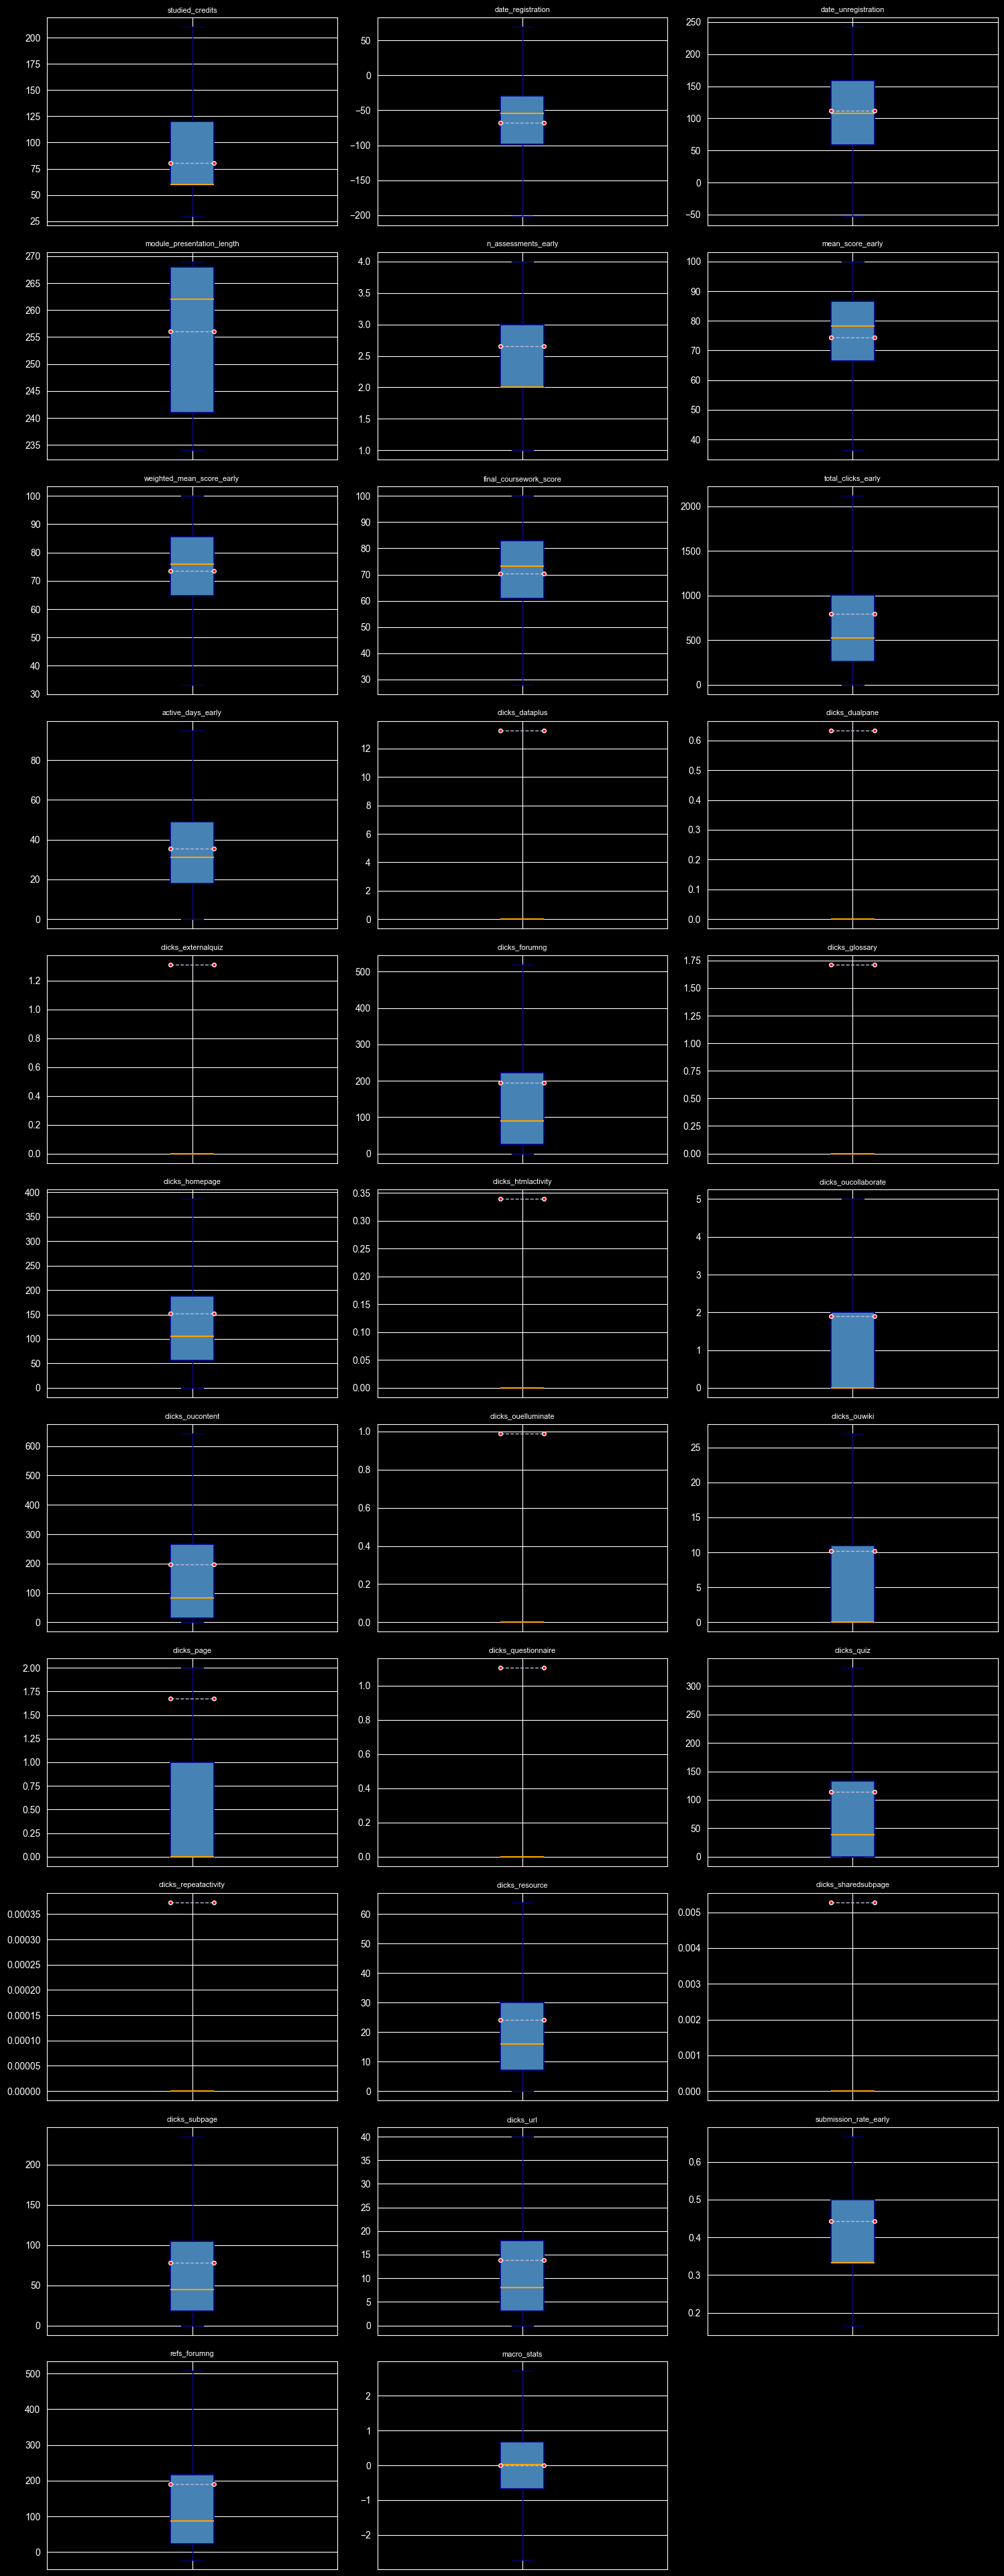

In [9]:
import math
import numpy as np
import matplotlib.pyplot as plt

n = len(continuous_columns)
columns_count = 3
rows_count = math.ceil(n / columns_count)

fig, axes = plt.subplots(rows_count, columns_count, figsize=(columns_count * 5, rows_count * 3.5))
axes = np.array(axes).flatten()

for i, column in enumerate(continuous_columns):
	ax = axes[i]

	data = train_data[column].dropna()
	if data.empty:
		ax.set_visible(False)
		continue

	train_data[[column]].boxplot(
		column=[column],
		ax=ax,
		patch_artist=True,
		showfliers=False,
		showmeans=True,
		meanline=True,
		boxprops=dict(facecolor="steelblue", edgecolor="navy", linewidth=1.2),
		whiskerprops=dict(color="navy", linewidth=1),
		capprops=dict(color="navy", linewidth=1),
		medianprops=dict(color="orange", linewidth=1.5),
		meanprops=dict(marker="o", markerfacecolor="red", markeredgecolor="white", markersize=4),
		grid=True,
	)

	ax.set_title(column, fontsize=8)
	ax.tick_params(axis="x", bottom=False, labelbottom=False)

	if data.skew() > 2 and (data > 0).all():
		ax.set_yscale("log")

for j in range(i + 1, len(axes)):
	axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [12]:
def analyze_discreate_columns(df):
	non_null_counts = []
	unique_counts = []

	for column in discrete_columns:
		non_null_counts.append(df[column].notnull().sum())
		unique_counts.append(df[column].nunique())

	return pd.DataFrame({
		"Column": discrete_columns,
		"Non-Null Count": non_null_counts,
		"Unique Count": unique_counts
	})


analyze_discreate_columns(train_data)


,Column,Non-Null Count,Unique Count
0,code_module,18802,6
1,code_presentation,18802,4
2,gender,18802,2
3,region,18802,13
4,highest_education,18802,5
5,imd_band,18028,10
6,age_band,18802,3
7,num_of_prev_attempts,18802,7
8,disability,18802,2
9,final_result,18802,4


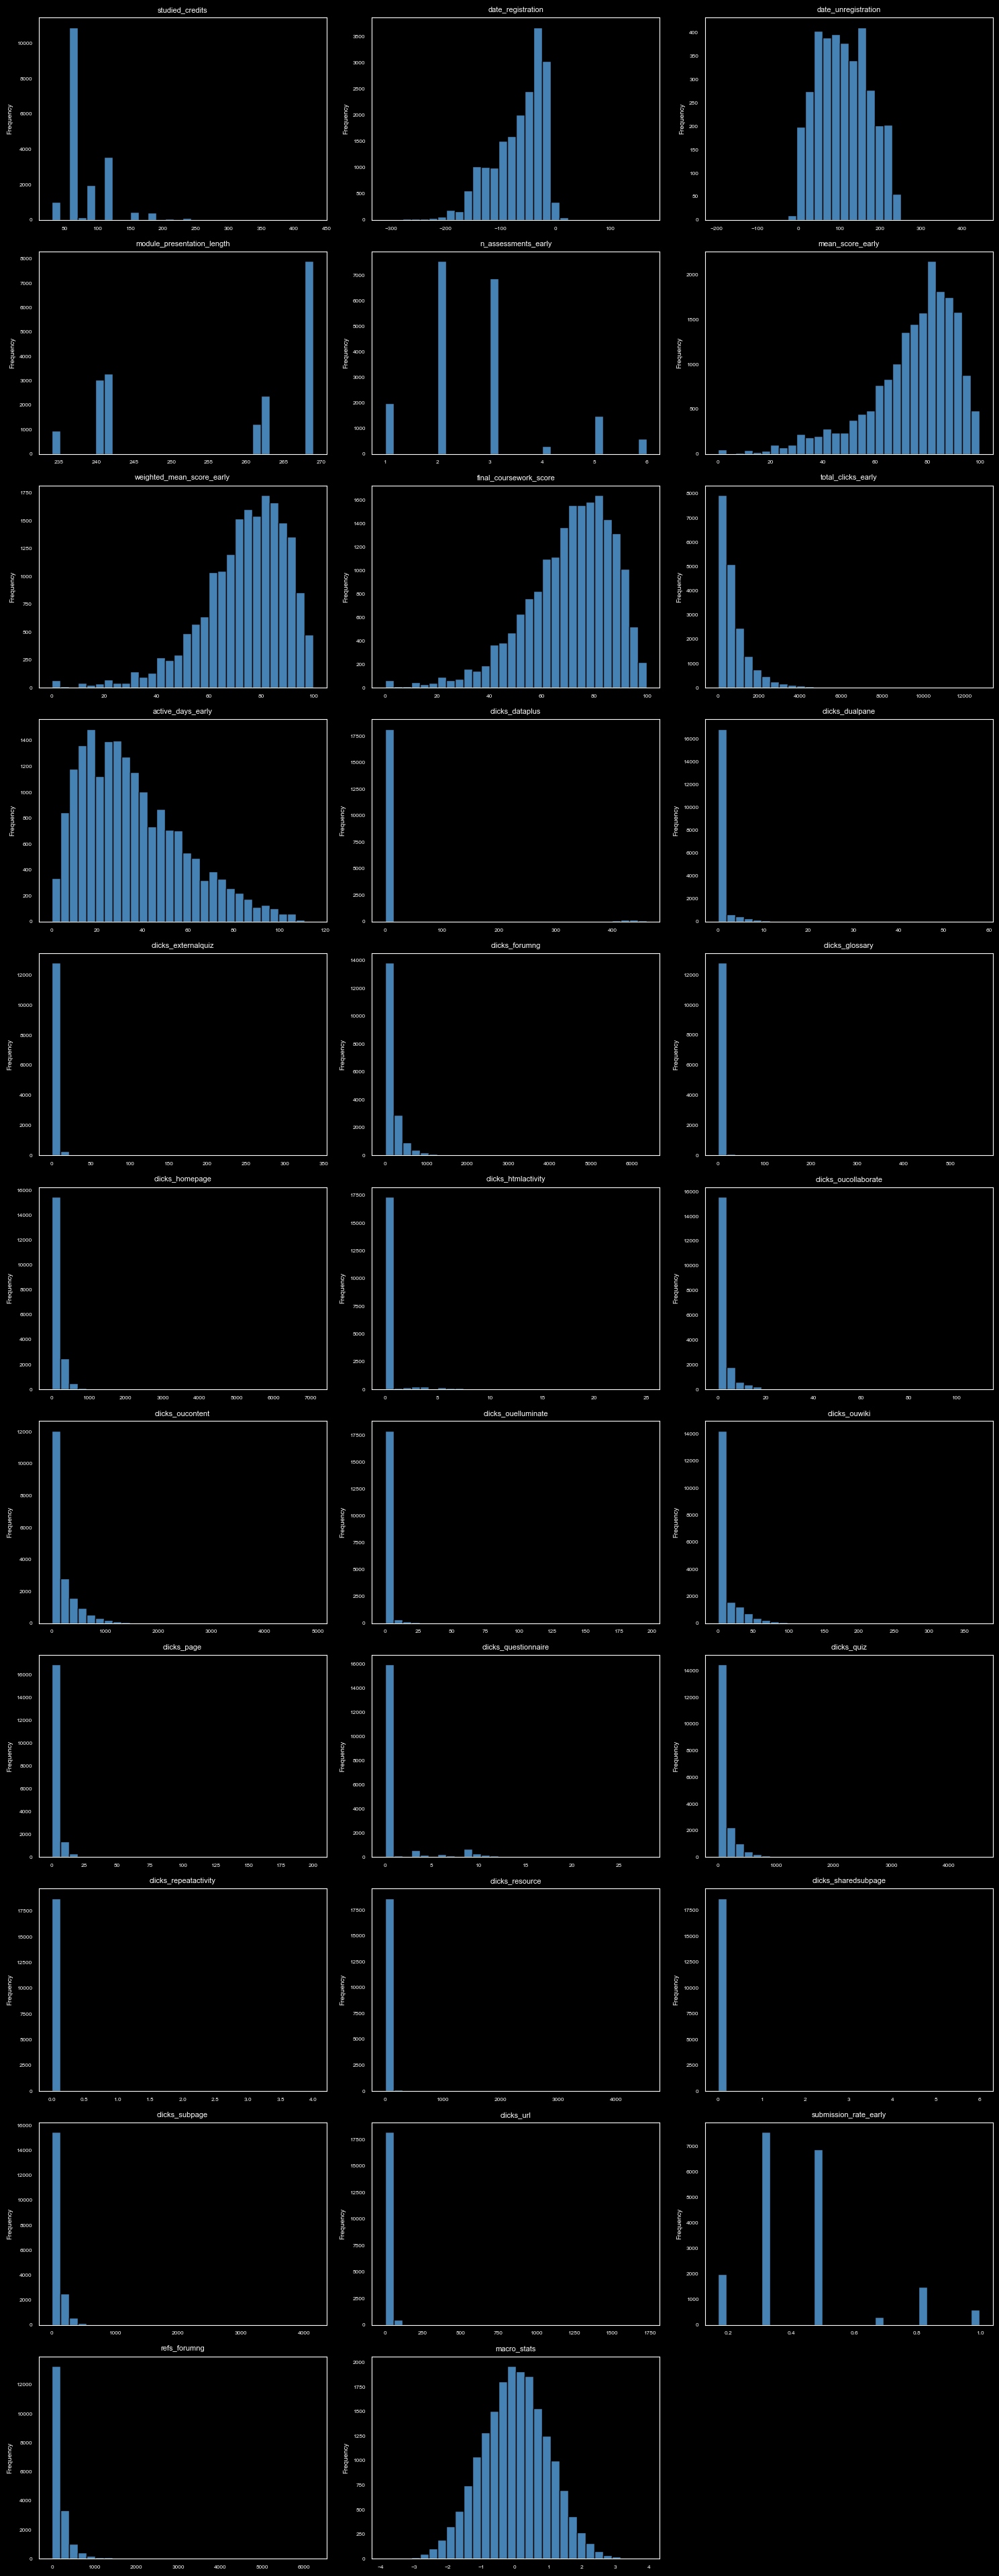

In [16]:
import math
import numpy as np
import matplotlib.pyplot as plt

n = len(continuous_columns)
columns_count = 3
rows_count = math.ceil(n / columns_count)

fig, axes = plt.subplots(rows_count, columns_count, figsize=(columns_count * 5, rows_count * 3.5))
axes = np.array(axes).flatten()

for i, column in enumerate(continuous_columns):
	ax = axes[i]

	data = train_data[column].dropna()
	if data.empty:
		ax.set_visible(False)
		continue

	# Plot histogram
	data.hist(ax=ax, bins=30, edgecolor='black', grid=False, color='steelblue')

	ax.set_title(column, fontsize=8)
	ax.set_ylabel('Frequency', fontsize=7)
	ax.tick_params(axis='x', labelsize=6)
	ax.tick_params(axis='y', labelsize=6)

	# log scale if highly skewed and positive
	if data.skew() > 2 and (data > 0).all():
		ax.set_yscale('log')

for j in range(i + 1, len(axes)):
	axes[j].set_visible(False)

plt.tight_layout()
plt.show()